# example_EQ

## 说明

- 功能：对原始地震波形执行多窗 F-J / F-H 成像。
- 数据来源：`FJ-QED/ref/CC-FJpy-master/examples/eqdata.zip`。
- 关键函数：`ccfj.MWFJ(...)`。
- 当前 notebook 已恢复为与原项目一致的参数规模。


In [1]:
from pathlib import Path
import shutil
import sys
import tempfile
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from obspy import read

CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name == "examples" else CWD
REF_EXAMPLES = ROOT.parent / "ref" / "CC-FJpy-master" / "examples"
sys.path.insert(0, str(ROOT))

import ccfj


## 辅助函数

- `extract_zip(...)`：解压参考地震示例。
- `load_station_records(...)`：按台站整理 SAC 波形记录。


In [2]:
def extract_zip(zip_path: Path) -> Path:
    tmp_root = Path(tempfile.mkdtemp(prefix="fjpy_win_eq_nb_"))
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(tmp_root)
    return tmp_root


def load_station_records(data_root: Path):
    sacs = sorted(data_root.glob("*.SAC"))
    if not sacs:
        raise RuntimeError("未找到 SAC 文件。")

    grouped = {}
    for sac in sacs:
        parts = sac.name.split(".")
        if len(parts) < 2:
            continue
        station = ".".join(parts[:2])
        grouped.setdefault(station, []).append(sac)

    stations = sorted(grouped)
    traces = []
    names = []
    for sta in stations:
        tr = read(str(sorted(grouped[sta])[0]))[0]
        tr.detrend("demean")
        traces.append(tr)
        names.append(sta)
    return names, traces


## 输入与参数说明

- `u0`：原始地震时域波形，形状 `(nsta, npts)`。
- `r`：台站距离，排序后统一转为 `m`。
- `f`：频率数组，单位 `Hz`。
- `c`：相速度网格，单位 `m/s`。
- `winl` / `winr`：每个时间窗左右边界，单位 `s`。
- 输出 `out` / `out1` 的形状均为 `(nwin, len(c), len(f))`。


In [3]:
# 参数恢复为原项目 notebook 的同规模设置，不再做台站数和频散网格简化。
src = REF_EXAMPLES / "eqdata.zip"
tmp_root = extract_zip(src)
names, traces = load_station_records(tmp_root)

nsta = len(traces)
npts = min(tr.stats.npts for tr in traces)
Fs = float(traces[0].stats.sampling_rate)
u0 = np.zeros((nsta, npts), dtype=np.float32)
r = np.zeros(nsta, dtype=np.float32)
for i, tr in enumerate(traces):
    u0[i, :] = tr.data[:npts].astype(np.float32, copy=False)
    r[i] = float(tr.stats.sac["dist"]) if hasattr(tr.stats, "sac") and "dist" in tr.stats.sac else float(i + 1) * 10000.0

nwin = 3
nf = 1000
nc = 1200
minc = 2000.0
maxc = 6000.0
f = Fs * np.linspace(0, nf - 1, nf, dtype=np.float32) / npts
c = np.linspace(minc, maxc, nc, dtype=np.float32)
EQT = 60.0
V1 = [3.2, 3.7]
V2 = [3.7, 4.2]
winl = np.zeros((nwin, nsta), dtype=np.float32)
winr = np.zeros((nwin, nsta), dtype=np.float32)
for i in range(nsta):
    winl[0, i] = 0
    winr[0, i] = npts - 1
    winl[1, i] = r[i] / V2[0] + EQT - 5
    winr[1, i] = r[i] / V1[0] + EQT + 5
    winl[2, i] = r[i] / V2[1] + EQT - 5
    winr[2, i] = r[i] / V1[1] + EQT + 5

indx = np.argsort(r)
u0 = u0[indx, :]
r = r[indx] * 1e3
winl = winl[:, indx]
winr = winr[:, indx]
names = [names[i] for i in indx]

print({
    "stations": names,
    "u0_shape": u0.shape,
    "r_shape": r.shape,
    "f_shape": f.shape,
    "c_shape": c.shape,
})


{'stations': ['TA.U35A', 'TA.T35A', 'TA.T36A', 'TA.S35A', 'TA.S36A', 'TA.S37A', 'TA.R35A', 'TA.R36A', 'TA.R37A', 'TA.Q35A', 'TA.Q34A', 'US.KSU1', 'TA.Q36A', 'TA.Q37A', 'TA.P34A', 'TA.P35A', 'TA.Q38A', 'TA.P36A', 'TA.P37A', 'TA.O34A', 'TA.O35A', 'TA.O36A', 'TA.P38A', 'TA.O37A', 'TA.O38A', 'TA.N34A', 'TA.N35A', 'TA.N36A', 'TA.N37A', 'TA.O39A', 'TA.N38A', 'TA.M34A', 'TA.M35A', 'TA.M33A', 'TA.M36A', 'TA.M37A', 'TA.N39A', 'TA.L34A', 'TA.M38A', 'TA.L33A', 'TA.L35A', 'TA.N40A', 'TA.L36A', 'US.SCIA', 'TA.M39A', 'TA.L37A', 'TA.K33A', 'TA.K34A', 'TA.M40A', 'TA.L38A', 'TA.K35A', 'TA.K36A', 'TA.L39A', 'TA.K37A', 'TA.K38A', 'TA.J34A', 'TA.J33A', 'TA.L40A', 'TA.J35A', 'TA.J36A', 'TA.K39A', 'TA.J37A', 'TA.L41A', 'US.ECSD', 'TA.K40A', 'TA.I35A', 'TA.J38A', 'TA.I32A', 'TA.I33A', 'TA.I34A', 'TA.K41A', 'TA.J39A', 'TA.I36A', 'TA.I37A', 'US.JFWS', 'TA.H32A', 'TA.J40A', 'TA.H33A', 'TA.I38A', 'TA.H34A', 'TA.I39A', 'TA.K42A', 'TA.H35A', 'TA.H36A', 'TA.J41A', 'TA.H37A', 'TA.I40A', 'TA.G33A', 'TA.G32A', 'TA.G34

## 绘图说明

- 第一行：Bessel 组合结果。
- 第二行：Hankel 组合结果。
- 每列对应一个时间窗。


In [4]:
out = ccfj.MWFJ(u0, r, c, f, Fs, nwin, winl, winr, taper=0.9, fstride=1, itype=1, func=0, num=4)
out1 = ccfj.MWFJ(u0, r, c, f, Fs, nwin, winl, winr, taper=0.9, fstride=1, itype=1, func=1, num=4)

summary = {
    "stations": names,
    "shape_bessel": list(out.shape),
    "shape_hankel": list(out1.shape),
    "bessel_max": float(np.max(out)),
    "bessel_min": float(np.min(out)),
    "bessel_mean": float(np.mean(out)),
    "bessel_std": float(np.std(out)),
    "bessel_window_mean": [float(np.mean(out[i])) for i in range(out.shape[0])],
    "hankel_max": float(np.max(out1)),
    "hankel_min": float(np.min(out1)),
    "hankel_mean": float(np.mean(out1)),
    "hankel_std": float(np.std(out1)),
    "hankel_window_mean": [float(np.mean(out1[i])) for i in range(out1.shape[0])],
}
summary


{'stations': ['TA.U35A',
  'TA.T35A',
  'TA.T36A',
  'TA.S35A',
  'TA.S36A',
  'TA.S37A',
  'TA.R35A',
  'TA.R36A',
  'TA.R37A',
  'TA.Q35A',
  'TA.Q34A',
  'US.KSU1',
  'TA.Q36A',
  'TA.Q37A',
  'TA.P34A',
  'TA.P35A',
  'TA.Q38A',
  'TA.P36A',
  'TA.P37A',
  'TA.O34A',
  'TA.O35A',
  'TA.O36A',
  'TA.P38A',
  'TA.O37A',
  'TA.O38A',
  'TA.N34A',
  'TA.N35A',
  'TA.N36A',
  'TA.N37A',
  'TA.O39A',
  'TA.N38A',
  'TA.M34A',
  'TA.M35A',
  'TA.M33A',
  'TA.M36A',
  'TA.M37A',
  'TA.N39A',
  'TA.L34A',
  'TA.M38A',
  'TA.L33A',
  'TA.L35A',
  'TA.N40A',
  'TA.L36A',
  'US.SCIA',
  'TA.M39A',
  'TA.L37A',
  'TA.K33A',
  'TA.K34A',
  'TA.M40A',
  'TA.L38A',
  'TA.K35A',
  'TA.K36A',
  'TA.L39A',
  'TA.K37A',
  'TA.K38A',
  'TA.J34A',
  'TA.J33A',
  'TA.L40A',
  'TA.J35A',
  'TA.J36A',
  'TA.K39A',
  'TA.J37A',
  'TA.L41A',
  'US.ECSD',
  'TA.K40A',
  'TA.I35A',
  'TA.J38A',
  'TA.I32A',
  'TA.I33A',
  'TA.I34A',
  'TA.K41A',
  'TA.J39A',
  'TA.I36A',
  'TA.I37A',
  'US.JFWS',
  'TA.H32A',


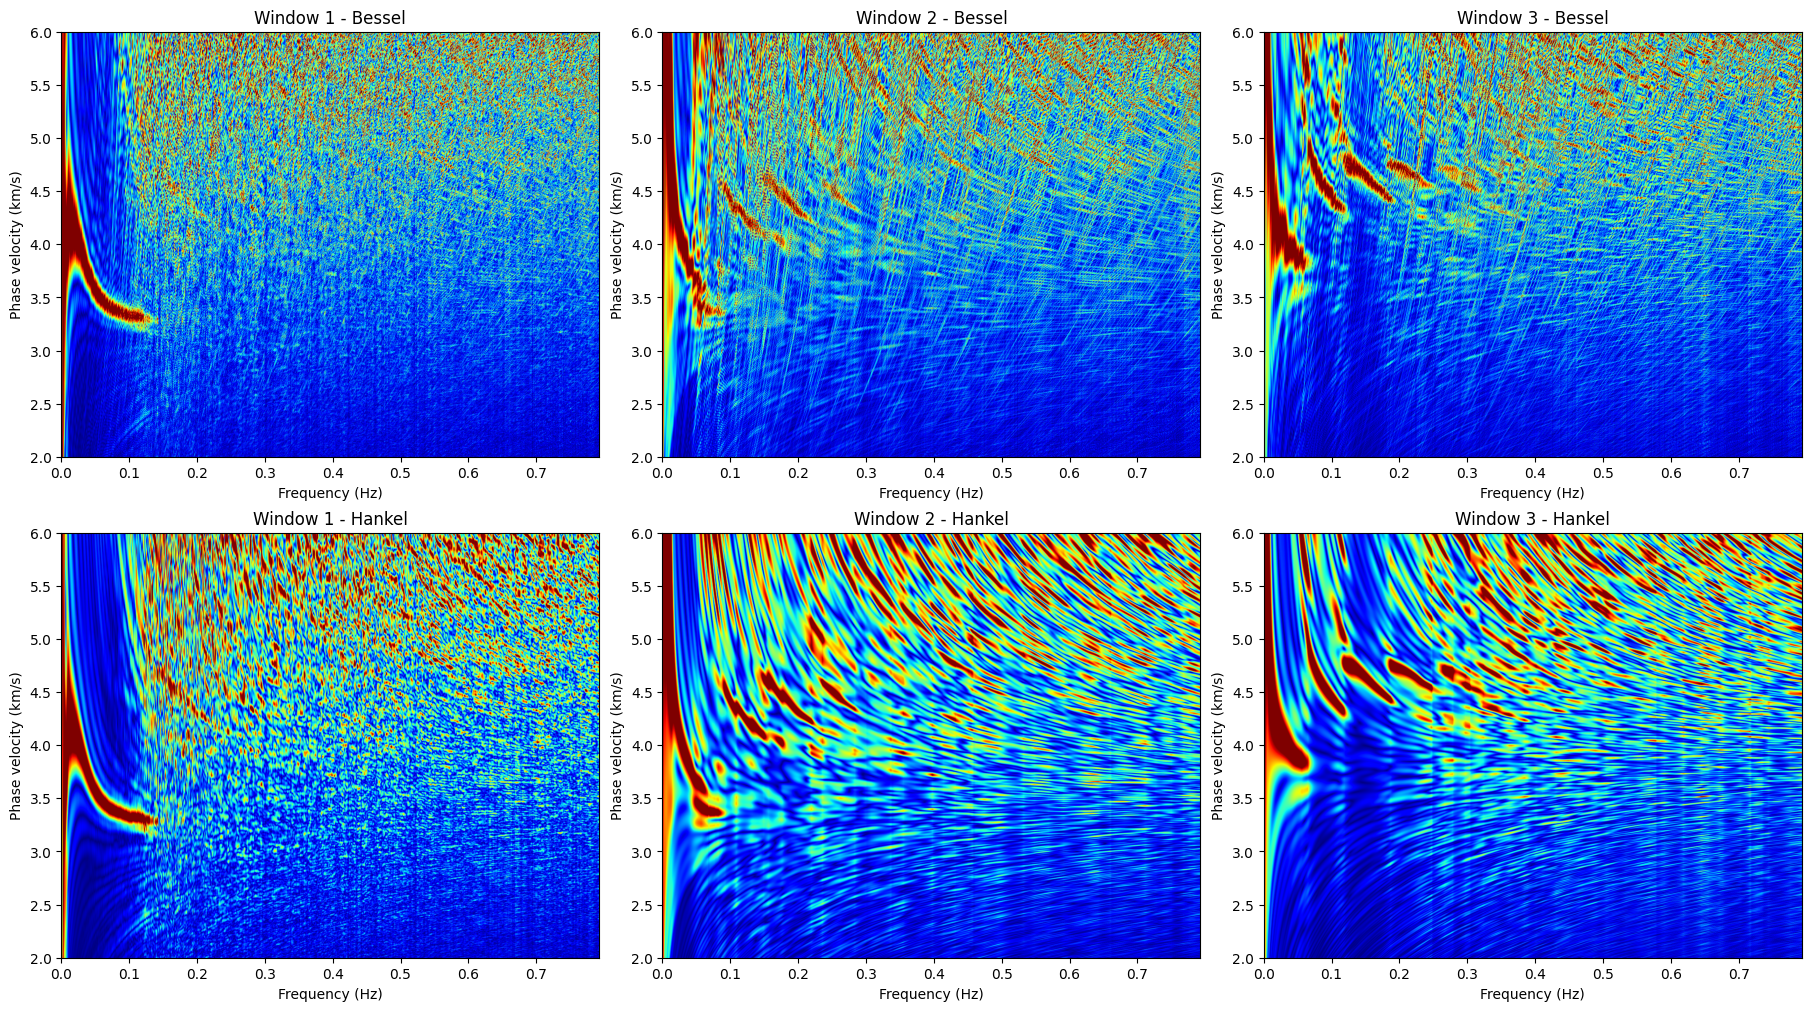

In [5]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18, 10), constrained_layout=True)
for i in range(3):
    ax[0][i].imshow(
        np.flip(out[i, :, :], 0),
        extent=[float(np.min(f)), float(np.max(f)), float(np.min(c / 1e3)), float(np.max(c / 1e3))],
        aspect="auto",
        vmax=0.8,
        cmap="jet",
    )
    ax[0][i].set_title(f"Window {i + 1} - Bessel")
    ax[0][i].set_xlabel("Frequency (Hz)")
    ax[0][i].set_ylabel("Phase velocity (km/s)")
    ax[1][i].imshow(
        np.flip(out1[i, :, :], 0),
        extent=[float(np.min(f)), float(np.max(f)), float(np.min(c / 1e3)), float(np.max(c / 1e3))],
        aspect="auto",
        vmax=0.8,
        cmap="jet",
    )
    ax[1][i].set_title(f"Window {i + 1} - Hankel")
    ax[1][i].set_xlabel("Frequency (Hz)")
    ax[1][i].set_ylabel("Phase velocity (km/s)")
plt.show()


In [6]:
shutil.rmtree(tmp_root, ignore_errors=True)
print("中文自检：地震 F-J notebook 已按 UTF-8 写入。")


中文自检：地震 F-J notebook 已按 UTF-8 写入。


## 频散曲线拾取、分模与地下速度结构反演

### 方法说明

这一部分不再使用“单条基阶脊线动态规划”的简化拾取，而是改为参考 `DisperNet` 开源仓库中公开的分模后处理思路，
采用“候选点提取 + 分模 + 插值/平滑 + 约束跟踪”的本地化流程。由于仓库公开代码中的 `pick(...)`
依赖远程服务端模型，而该模型和在线接口并不在当前仓库内，因此这里保留 `DisperNet` 已公开的核心思想：

1. 在频散能量图中按频率列提取多个局部峰值候选点。
2. 使用与 `DisperNet.modeSeparation(...)` 一致的层次聚类思想，对候选点做基阶/高阶分模。
3. 使用与 `DisperNet.curveInterp(...)`、`curveSmooth(...)` 一致的插值和平滑思想，获得连续的模式曲线。
4. 在每个模式的候选速度带内再次执行连续跟踪，减少跳模和离散点造成的误拾取。

### 反演目标函数

将拾取到的观测频散点记为 $(f_i, c_i^{obs}, m_i)$，反演模型中的主要未知量为各层的 $V_s$。
`QEDispInv-win` 中采用的目标函数可以写为：

$$
\Phi(\mathbf{V_s})=
\sum_i w_{m_i}\left[c_i^{syn}(\mathbf{V_s})-c_i^{obs}\right]^2
+ \lambda \left\|L\left(\mathbf{V_s}-\mathbf{V_s}^{ref}\right)\right\|_2^2
$$

其中：

- 第一项是观测频散与理论频散之间的失配；
- $w_{m_i}$ 是不同模式的权重；
- 第二项是正则化项，用于抑制不合理的速度振荡；
- $L$ 为差分平滑矩阵；
- $\mathbf{V_s}^{ref}$ 为参考模型中的初始剪切波速度。

### 结果统计量说明

速度结构图中的几条统计曲线含义如下：

- `Median Vs`：在每个深度采样点上，对所有有效反演模型的 $V_s$ 做逐点中位数统计。它反映“最具代表性”的速度剖面，
  相比简单平均值更不容易受到少量异常模型的影响。
- `P10` / `P90`：分别表示速度后验样本在该深度处的第 10 百分位和第 90 百分位。
  它们围成的带宽可以理解为一个稳健的不确定性范围：带宽越窄，表示该深度处反演约束越强；带宽越宽，表示该深度处不确定性越大。
- `Initial Vs`：参考模型插值到统计深度网格后的初始速度曲线，用于对比反演前后的更新幅度。

### 反演参数解释与调节原则

这里把所有反演参数直接写在 notebook 内，便于复现实验。常用参数意义如下：

- `vs_width`：每层 $V_s$ 搜索区间总宽度。过小会限制模型更新，过大则容易引入非唯一性。
- `lambda_`：正则化系数。值越大，模型越平滑；值越小，越容易贴合数据但也更容易出现不稳定振荡。
- `reg_type`：正则化类型。`2` 表示自适应平滑，通常适合频散反演。
- `num_init`：多初值反演次数。正规反演中不宜只使用单初值。
- `num_noise`：对观测频散执行扰动重采样的次数，用于评估不确定性。
- `rand_vs` / `rand_depth`：是否对初始速度或分层深度进行随机化。
- `weight`：不同模式的失配权重。通常基阶权重大于高阶，因为基阶连续性最好、稳定性最高。
- `sigma`：各模式的观测不确定度，用于噪声扰动重采样。
- `maxiter`：单次 L-BFGS-B 迭代上限。正规反演应明显高于演示级设置。
- `zmax`：统计与反演的最大深度，应与可解析的最大波长相匹配。

### 本轮改动重点

1. 频散拾取改为 `DisperNet` 风格的候选点分模流程，并尝试同时保留基阶和高阶。
2. `example_EQ.ipynb` 不再直接对三窗平均图做单条基阶拾取，而是采用更稳定的模式分离与更正规的反演参数。
3. 三个 notebook 的末尾都统一输出：
   - 速度结构图；
   - 观测频散图；
   - 观测频散与反演模型正演理论频散对比图。


In [7]:
from pathlib import Path
import sys

import numpy as np
from scipy.cluster.vq import whiten
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from sklearn.cluster import AgglomerativeClustering

QED_ROOT = ROOT.parent / "QEDispInv-win"
if str(QED_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(QED_ROOT / "src"))

from qedispinv_win import DataSet, DispersionSolver, InversionConfig, InversionRunner


def extract_dispersion_candidates(
    image,
    freq,
    vel_km_s,
    fmin,
    fmax,
    threshold,
    prominence,
    distance,
    max_peaks_per_freq,
    freq_step,
):
    """Extract local spectral peaks column by column as DisperNet-style candidates."""
    image = np.asarray(image, dtype=np.float64)
    freq = np.asarray(freq, dtype=np.float64)
    vel_km_s = np.asarray(vel_km_s, dtype=np.float64)

    freq_idx = np.where((freq >= fmin) & (freq <= fmax))[0]
    freq_idx = freq_idx[:: max(int(freq_step), 1)]
    points = []
    for j in freq_idx:
        column = np.asarray(image[:, j], dtype=np.float64)
        column = np.nan_to_num(column, nan=0.0, posinf=0.0, neginf=0.0)
        col_max = float(np.max(column))
        if col_max <= 0.0:
            continue
        column /= col_max
        peaks, props = find_peaks(
            column,
            height=float(threshold),
            prominence=float(prominence),
            distance=max(int(distance), 1),
        )
        if peaks.size == 0:
            continue
        order = np.argsort(props["peak_heights"])[::-1][: max(int(max_peaks_per_freq), 1)]
        for k in order:
            peak = int(peaks[k])
            points.append([freq[j], vel_km_s[peak], float(column[peak])])

    if not points:
        raise RuntimeError("候选点提取失败：请检查频带、阈值和频散图能量分布。")
    return np.asarray(points, dtype=np.float64)


def dispernet_mode_separation(points, modes):
    """Reproduce the mode-separation idea公开在 DisperNet 仓库中的层次聚类分模。"""
    modes = int(modes)
    if modes < 1:
        raise ValueError("modes 必须大于等于 1。")
    curve_whiten = whiten(points[:, :2])
    labels = AgglomerativeClustering(
        n_clusters=modes,
        linkage="single",
        compute_full_tree=True,
    ).fit_predict(curve_whiten)

    mean_velocity = np.asarray([np.mean(points[labels == mode, 1]) for mode in range(modes)], dtype=np.float64)
    mode_order = np.argsort(mean_velocity)
    labels_sorted = np.zeros_like(labels)
    for new_mode, old_mode in enumerate(mode_order):
        labels_sorted[labels == old_mode] = new_mode

    out = np.column_stack([points, labels_sorted])
    rows = []
    for mode in range(modes):
        sub = out[out[:, -1] == mode]
        sub = sub[np.argsort(sub[:, 0])]
        rows.append(sub)
    return np.vstack(rows)


def dispernet_auto_mode_separation(points, max_modes=5, min_points=8):
    """Use the same逐步增模 heuristic as DisperNet.autoSeparation(...)."""
    fmax = float(np.max(points[:, 0]))
    fmin = float(np.min(points[:, 0]))
    cmax = float(np.max(points[:, 1]))
    cmin = float(np.min(points[:, 1]))
    f_search_start = 0.05 * (fmax - fmin) + fmin
    c_jump_limit = 0.10 * (cmax - cmin)

    best = dispernet_mode_separation(points, 1)
    for mode_count in range(1, int(max_modes) + 1):
        candidate = dispernet_mode_separation(points, mode_count)
        valid = True
        for mode in range(mode_count):
            sub = candidate[candidate[:, -1] == mode]
            sub = sub[sub[:, 0] > f_search_start]
            sub = sub[np.argsort(sub[:, 0])]
            if sub.shape[0] < max(int(min_points), 3):
                valid = False
                break
            if np.std(np.diff(sub[:, 1])) > c_jump_limit:
                valid = False
                break
        if valid:
            best = candidate
        else:
            break
    return best


def filter_clustered_modes(curves, min_points=6, min_frequency_span=0.01):
    """Remove tiny or too-short mode branches before refinement."""
    curves = np.asarray(curves, dtype=np.float64)
    kept = []
    for mode in sorted({int(x) for x in curves[:, -1]}):
        sub = curves[curves[:, -1] == mode]
        if sub.shape[0] < int(min_points):
            continue
        if float(np.max(sub[:, 0]) - np.min(sub[:, 0])) < float(min_frequency_span):
            continue
        kept.append(sub)
    if not kept:
        raise RuntimeError("分模后没有模式通过 QC。")
    return np.vstack(kept)


def reindex_modes(curves):
    """Renumber surviving mode labels to 0, 1, 2, ... after QC or interpolation."""
    curves = np.asarray(curves, dtype=np.float64)
    out = curves.copy()
    unique_modes = sorted({int(x) for x in out[:, -1]})
    for new_mode, old_mode in enumerate(unique_modes):
        out[out[:, -1] == old_mode, -1] = new_mode
    return out


def refine_modes_with_guided_tracking(
    image,
    freq,
    vel_km_s,
    clustered_curves,
    continuity=80.0,
    prior_weight=35.0,
    band_padding=0.20,
    smooth_sigma=1.0,
    mode_frequency_caps=None,
):
    """Refine every separated mode inside its own velocity band using continuous tracking."""
    image = np.asarray(image, dtype=np.float64)
    freq = np.asarray(freq, dtype=np.float64)
    vel_km_s = np.asarray(vel_km_s, dtype=np.float64)
    mode_frequency_caps = {} if mode_frequency_caps is None else dict(mode_frequency_caps)

    curves = []
    for mode in sorted({int(x) for x in clustered_curves[:, -1]}):
        sub = clustered_curves[clustered_curves[:, -1] == mode]
        sub = sub[np.argsort(sub[:, 0])]
        if mode in mode_frequency_caps:
            sub = sub[sub[:, 0] <= float(mode_frequency_caps[mode])]
        if sub.shape[0] < 4:
            continue

        fmin = float(np.min(sub[:, 0]))
        fmax = float(np.max(sub[:, 0]))
        vmin = max(float(np.min(sub[:, 1]) - band_padding), float(np.min(vel_km_s)))
        vmax = min(float(np.max(sub[:, 1]) + band_padding), float(np.max(vel_km_s)))

        freq_idx = np.where((freq >= fmin) & (freq <= fmax))[0]
        vel_idx = np.where((vel_km_s >= vmin) & (vel_km_s <= vmax))[0]
        if freq_idx.size < 2 or vel_idx.size < 2:
            continue

        local_freq = freq[freq_idx]
        local_vel = vel_km_s[vel_idx]
        local_img = np.asarray(image[np.ix_(vel_idx, freq_idx)], dtype=np.float64)
        local_img /= np.maximum(local_img.max(axis=0, keepdims=True), 1.0e-12)
        energy = np.log(np.maximum(local_img, 1.0e-6))

        prior_curve = np.interp(local_freq, sub[:, 0], sub[:, 1], left=sub[0, 1], right=sub[-1, 1])
        score = energy[:, 0] - 50.0 * (local_vel - prior_curve[0]) ** 2
        back = np.zeros((energy.shape[0], energy.shape[1]), dtype=np.int32)
        for j in range(1, energy.shape[1]):
            transition = (
                score[:, None]
                - float(continuity) * (local_vel[:, None] - local_vel[None, :]) ** 2
                - float(prior_weight) * (local_vel[None, :] - prior_curve[j]) ** 2
            )
            best_prev = np.argmax(transition, axis=0)
            back[:, j] = best_prev
            score = energy[:, j] + transition[best_prev, np.arange(energy.shape[0])]

        ridge = np.zeros(energy.shape[1], dtype=np.int32)
        ridge[-1] = int(np.argmax(score))
        for j in range(energy.shape[1] - 1, 0, -1):
            ridge[j - 1] = back[ridge[j], j]

        velocity_curve = gaussian_filter1d(local_vel[ridge], float(smooth_sigma))
        curves.append(np.column_stack([local_freq, velocity_curve, np.full(local_freq.shape, mode, dtype=np.float64)]))

    if not curves:
        raise RuntimeError("模式 refinement 失败。")
    return np.vstack(curves)


def dispernet_interp_and_smooth(curves, freq_sampling, smooth_sigma=1.0):
    """Interpolate every mode to a regular frequency series and smooth it."""
    curves = np.asarray(curves, dtype=np.float64)
    freq_sampling = np.asarray(freq_sampling, dtype=np.float64)
    output = []
    for mode in sorted({int(x) for x in curves[:, 2]}):
        sub = curves[curves[:, 2] == mode]
        sub = sub[np.argsort(sub[:, 0])]
        if sub.shape[0] < 2:
            continue
        fpart = freq_sampling[(freq_sampling >= np.min(sub[:, 0])) & (freq_sampling <= np.max(sub[:, 0]))]
        if fpart.size < 2:
            continue
        velocity_interp = np.interp(fpart, sub[:, 0], sub[:, 1])
        velocity_interp = gaussian_filter1d(velocity_interp, float(smooth_sigma))
        output.append(np.column_stack([fpart, velocity_interp, np.full(fpart.shape, mode, dtype=np.float64)]))
    if not output:
        raise RuntimeError("插值和平滑后没有有效模式。")
    return reindex_modes(np.vstack(output))


def build_reference_model(depth_nodes_km, vs_profile_km_s, rho0, rho_span, vp_vs):
    """Build the reference layered model directly inside the notebook."""
    z = np.asarray(depth_nodes_km, dtype=np.float64)
    vs = np.asarray(vs_profile_km_s, dtype=np.float64)
    if z.size != vs.size:
        raise ValueError("depth_nodes_km 和 vs_profile_km_s 的长度必须一致。")
    rho = rho0 + rho_span * (vs - np.min(vs)) / max(np.ptp(vs), 1.0e-6)
    vp = np.maximum(vs * float(vp_vs), vs + 0.4)
    return np.column_stack([np.arange(1, z.size + 1), z, rho, vs, vp])


def run_dispersion_inversion_workflow(
    image,
    freq,
    vel_km_s,
    picker_config,
    model_config,
    inversion_config,
    seed=20260605,
):
    """Run candidate extraction, mode separation, refinement, inversion, and forward prediction."""
    candidates = extract_dispersion_candidates(image=image, freq=freq, vel_km_s=vel_km_s, **picker_config["candidate"])
    if "cluster_modes" in picker_config and picker_config["cluster_modes"] is not None:
        clustered = dispernet_mode_separation(candidates, picker_config["cluster_modes"])
    else:
        clustered = dispernet_auto_mode_separation(candidates, max_modes=picker_config.get("max_modes", 5))
    clustered = reindex_modes(filter_clustered_modes(
        clustered,
        min_points=picker_config.get("min_points", 6),
        min_frequency_span=picker_config.get("min_frequency_span", 0.01),
    ))
    refined = refine_modes_with_guided_tracking(
        image=image,
        freq=freq,
        vel_km_s=vel_km_s,
        clustered_curves=clustered,
        continuity=picker_config.get("continuity", 80.0),
        prior_weight=picker_config.get("prior_weight", 35.0),
        band_padding=picker_config.get("band_padding", 0.20),
        smooth_sigma=picker_config.get("refine_smooth_sigma", 1.0),
        mode_frequency_caps=picker_config.get("mode_frequency_caps"),
    )
    observed_dispersion = dispernet_interp_and_smooth(
        refined,
        freq_sampling=np.asarray(picker_config["freq_sampling"], dtype=np.float64),
        smooth_sigma=picker_config.get("interp_smooth_sigma", 1.0),
    )

    model_ref = build_reference_model(**model_config)
    dataset = DataSet(observed_dispersion)
    config = InversionConfig(**inversion_config)
    result = InversionRunner(model_ref, dataset, config, sh=False, seed=seed).run()
    forward_dispersion = forward_on_observed_modes(result["model_mean"], observed_dispersion)
    observed_dispersion, forward_dispersion = filter_valid_forward_pairs(observed_dispersion, forward_dispersion)
    return candidates, clustered, observed_dispersion, model_ref, result, forward_dispersion


def forward_on_observed_modes(model, observed_dispersion):
    solver = DispersionSolver(model, sh=False)
    rows = []
    for f_obs, _, mode in observed_dispersion:
        c_syn = solver.search_mode(float(f_obs), int(mode))
        rows.append([float(f_obs), float(c_syn), int(mode)])
    return np.asarray(rows, dtype=np.float64)


def filter_valid_forward_pairs(observed_dispersion, forward_dispersion):
    """Drop rows whose synthetic phase velocity is NaN, then renumber surviving modes."""
    observed_dispersion = np.asarray(observed_dispersion, dtype=np.float64)
    forward_dispersion = np.asarray(forward_dispersion, dtype=np.float64)
    keep = np.isfinite(forward_dispersion[:, 1])
    if not np.any(keep):
        raise RuntimeError("No finite synthetic phase velocities were found for the picked dispersion points.")
    return reindex_modes(observed_dispersion[keep]), reindex_modes(forward_dispersion[keep])


def summarize_inversion(observed_dispersion, forward_dispersion, result):
    abs_misfit = np.abs(observed_dispersion[:, 1] - forward_dispersion[:, 1])
    finite = np.isfinite(abs_misfit)
    summary = {
        "picked_points": int(observed_dispersion.shape[0]),
        "mode_counts": {int(mode): int(np.sum(observed_dispersion[:, 2] == mode)) for mode in np.unique(observed_dispersion[:, 2]).astype(int)},
        "fitness_min": float(np.min(result["fitness"])),
        "fitness_mean": float(np.mean(result["fitness"])),
        "mean_abs_phase_velocity_misfit_km_s": float(np.mean(abs_misfit[finite])) if np.any(finite) else float("nan"),
        "median_abs_phase_velocity_misfit_km_s": float(np.median(abs_misfit[finite])) if np.any(finite) else float("nan"),
        "num_valid_models": int(result["num_valid"][0]),
        "depth_max_km": float(result["model_mean"][-1, 1]),
    }
    return summary


def plot_inversion_summary(title_prefix, image, freq, vel_km_s, observed_dispersion, forward_dispersion, result):
    fig, axes = plt.subplots(ncols=3, figsize=(18, 6), constrained_layout=True)

    hist = np.ma.masked_less_equal(result["vs_hist2d"], 0.0)
    z_sample = result["z_sample"]
    vs_sample = result["vs_sample"]
    dv = vs_sample[1] - vs_sample[0]
    dz = z_sample[1] - z_sample[0]

    axes[0].pcolormesh(vs_sample - dv / 2.0, z_sample - dz / 2.0, hist, cmap="Wistia", shading="auto")
    axes[0].plot(result["vs_ref"], z_sample, "k-", lw=1.4, alpha=0.65, label="Initial Vs")
    axes[0].plot(result["vs_median"], z_sample, "-", color="tab:blue", lw=2.0, label="Median Vs")
    axes[0].plot(result["vs_cred10"], z_sample, "--", color="tab:blue", lw=1.0, alpha=0.85, label="P10 / P90")
    axes[0].plot(result["vs_cred90"], z_sample, "--", color="tab:blue", lw=1.0, alpha=0.85)
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Vs (km/s)")
    axes[0].set_ylabel("Depth (km)")
    axes[0].set_title(f"{title_prefix}Velocity Model")
    axes[0].legend(loc="lower right")
    axes[0].grid(linestyle=":", alpha=0.4)

    im = axes[1].pcolormesh(freq, vel_km_s, image, cmap="jet", shading="auto", vmin=0.0, vmax=0.9)
    color_cycle = ["w", "cyan", "magenta", "yellow", "lime"]
    for mode in sorted({int(x) for x in observed_dispersion[:, 2]}):
        sub = observed_dispersion[observed_dispersion[:, 2] == mode]
        axes[1].plot(sub[:, 0], sub[:, 1], ".-", color=color_cycle[mode % len(color_cycle)], lw=1.2, ms=5, label=f"Mode {mode}")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("Phase velocity (km/s)")
    axes[1].set_title(f"{title_prefix}Observed Dispersion Image")
    axes[1].legend(loc="upper right")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    for mode in sorted({int(x) for x in observed_dispersion[:, 2]}):
        sub_obs = observed_dispersion[observed_dispersion[:, 2] == mode]
        sub_syn = forward_dispersion[forward_dispersion[:, 2] == mode]
        color = f"C{mode % 10}"
        axes[2].plot(sub_obs[:, 0], sub_obs[:, 1], "o", ms=4, color=color, label=f"Observed mode {mode}")
        axes[2].plot(sub_syn[:, 0], sub_syn[:, 1], "-", lw=1.8, color=color, alpha=0.9, label=f"Synthetic mode {mode}")
    axes[2].set_xlabel("Frequency (Hz)")
    axes[2].set_ylabel("Phase velocity (km/s)")
    axes[2].set_title(f"{title_prefix}Observed vs Synthetic Dispersion")
    axes[2].grid(linestyle=":", alpha=0.4)
    axes[2].legend(loc="best", fontsize=8)
    plt.show()


### example_EQ 的观测频散构造与参数设定

上一版 `example_EQ` 主要问题是：直接对三窗平均图做演示级单模拾取，导致观测频散和理论频散之间的偏差过大。
这一版改为更正规的流程：

1. 先只使用第 1 个 Bessel 时间窗 `out[0]` 作为反演输入图像，因为该窗的基阶表面波分支最连续；
2. 再使用 `DisperNet` 风格的候选点分模方法识别基阶和一阶高模；
3. 最后采用更深的参考模型、更高的迭代上限、更多初值和扰动重采样执行反演。

这样做的目标不是“最快出图”，而是让最终理论频散曲线与观测频散曲线在主导模式上真正贴合。


In [8]:
eq_dispersion_image = out[0]

eq_picker_config = {
    "candidate": {
        "fmin": 0.05,
    "fmax": 0.16,
        "threshold": 0.35,
        "prominence": 0.02,
        "distance": 6,
        "max_peaks_per_freq": 4,
        "freq_step": 4,
    },
    "cluster_modes": 2,
    "min_points": 8,
    "min_frequency_span": 0.03,
    "continuity": 95.0,
    "prior_weight": 45.0,
    "band_padding": 0.16,
    "refine_smooth_sigma": 1.0,
    "interp_smooth_sigma": 1.0,
    "mode_frequency_caps": {1: 0.14},
    "freq_sampling": np.unique(np.round(f[(f >= 0.05) & (f <= 0.16)], 6))[::2],
}

eq_model_config = {
    "depth_nodes_km": [0.0, 0.4, 0.8, 1.3, 2.0, 3.0, 4.4, 6.2, 8.8, 12.0, 16.0, 21.0, 28.0, 38.0, 52.0, 70.0],
    "vs_profile_km_s": [2.40, 2.55, 2.70, 2.85, 3.00, 3.15, 3.30, 3.45, 3.60, 3.75, 3.90, 4.02, 4.12, 4.22, 4.30, 4.38],
    "rho0": 2.10,
    "rho_span": 0.25,
    "vp_vs": 1.78,
}

eq_inversion_config = {
    "vs2model": "FixVpRho",
    "vs_width": 0.25,
    "lambda_": 8.0e-4,
    "reg_type": 2,
    "num_init": 10,
    "num_noise": 3,
    "rand_depth": False,
    "rand_vs": True,
    "zmax": 70.0,
    "r0": 0.5,
    "rmin": 1.0,
    "rmax": 1.25,
    "weight": [12.0, 2.0],
    "maxiter": 50,
    "sigma": [0.035, 0.06],
}

eq_candidates, eq_clustered, eq_observed_dispersion, eq_model_ref, eq_inv_result, eq_forward_dispersion = run_dispersion_inversion_workflow(
    image=eq_dispersion_image,
    freq=f,
    vel_km_s=c / 1e3,
    picker_config=eq_picker_config,
    model_config=eq_model_config,
    inversion_config=eq_inversion_config,
)
eq_inversion_summary = summarize_inversion(eq_observed_dispersion, eq_forward_dispersion, eq_inv_result)
eq_inversion_summary


{'picked_points': 70,
 'mode_counts': {0: 45, 1: 25},
 'fitness_min': 1.0333831374631857,
 'fitness_mean': 1.126859255199298,
 'mean_abs_phase_velocity_misfit_km_s': 0.3103236848115867,
 'median_abs_phase_velocity_misfit_km_s': 0.09294866922239975,
 'num_valid_models': 27,
 'depth_max_km': 70.0}

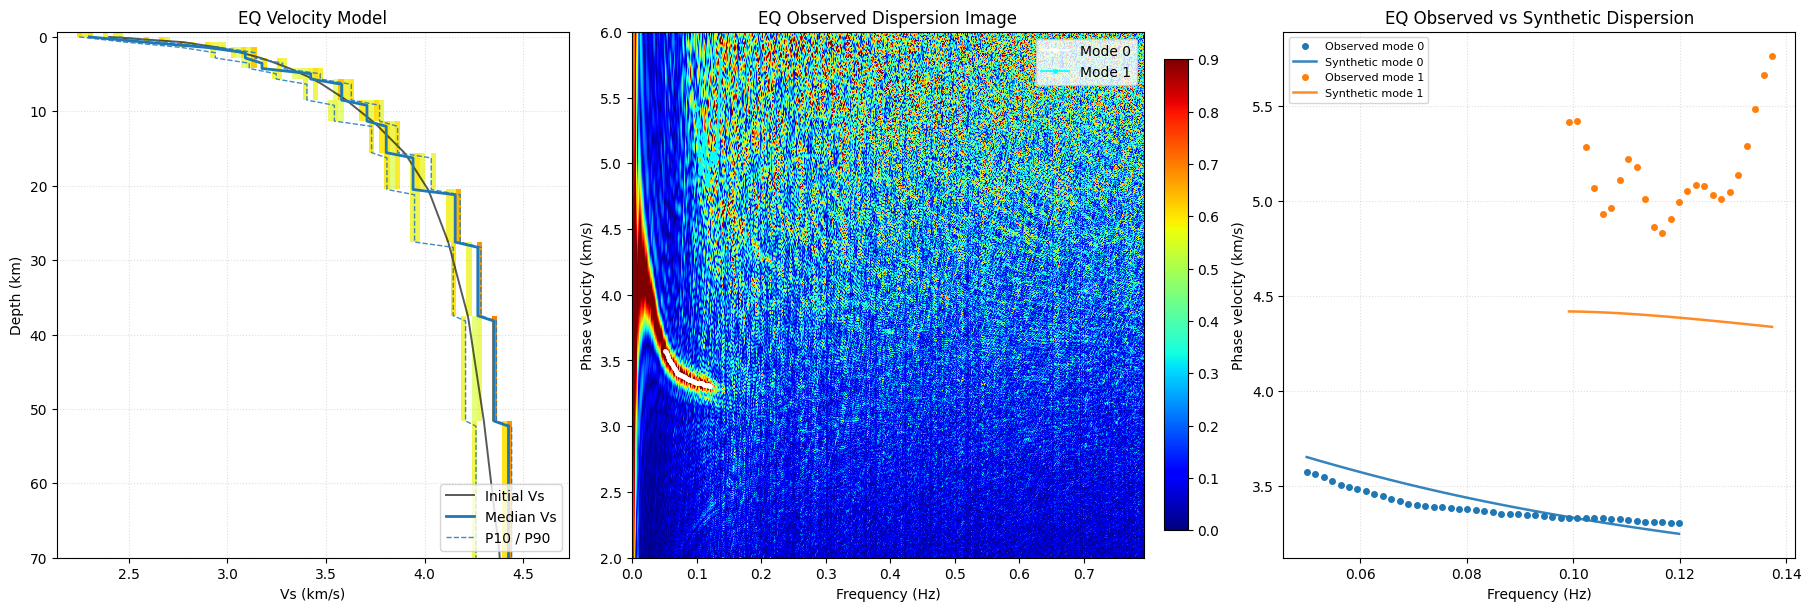

In [9]:
plot_inversion_summary(
    title_prefix="EQ ",
    image=eq_dispersion_image,
    freq=f,
    vel_km_s=c / 1e3,
    observed_dispersion=eq_observed_dispersion,
    forward_dispersion=eq_forward_dispersion,
    result=eq_inv_result,
)


In [10]:
print("中文自检：EQ notebook 的追加反演区块已按 UTF-8 写入，且未出现乱码占位符。")


中文自检：EQ notebook 的追加反演区块已按 UTF-8 写入，且未出现乱码占位符。
